# Classical Ising temperature sweep and thermodynamic observables

**Research question:** How do energy and magnetic order vary with temperature for the finite \(L=20\) model, and over which sampled interval do the curves change most rapidly?

The complete temperature sweep is run by:

```text
python scripts/run_ising_temperature_sweep.py --config configs/ising_final.yaml
```

This notebook loads the saved result. It contains no second copy of the Metropolis implementation.

**Source:** Tong, Section 5.2, printed pp. 147–148, for the Hamiltonian and magnetisation; Tong, Section 5.2.3, printed p. 154, for finite-system rounding; Tong, Section 5.3.4, printed pp. 165–166, for the exact infinite-lattice benchmark.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start: Path) -> Path:
    """Find the repository root from either the root or a notebook folder."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml above the working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Project root: {PROJECT_ROOT}")

import csv
import json

from ising2d.dataset import load_npz, split_half_means
from ising2d.observables import exact_square_lattice_critical_temperature

RESULT_PATH = PROJECT_ROOT / "results" / "raw" / "ising_day22_temperature_sweep.npz"
SUMMARY_PATH = PROJECT_ROOT / "results" / "processed" / "ising_day22_temperature_sweep_summary.csv"
METADATA_PATH = PROJECT_ROOT / "results" / "raw" / "ising_day22_temperature_sweep_metadata.json"
DIAGNOSTIC_PATH = PROJECT_ROOT / "results" / "raw" / "ising_day22_initial_condition_diagnostics.npz"
FIGURE_DIR = PROJECT_ROOT / "figures" / "exploratory" / "classical" / "day22"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for required_path in (RESULT_PATH, SUMMARY_PATH, METADATA_PATH):
    if not required_path.exists():
        raise FileNotFoundError(
            f"Missing {required_path}. Run the YAML-driven experiment script first."
        )

sweep = load_npz(RESULT_PATH)
with METADATA_PATH.open("r", encoding="utf-8") as handle:
    metadata = json.load(handle)

TC_EXACT = exact_square_lattice_critical_temperature()
print(f"Loaded: {RESULT_PATH}")
print(f"Experiment: {metadata['experiment_name']}")


Project root: /mnt/data/ising-phase-transitions
Loaded: /mnt/data/ising-phase-transitions/results/raw/ising_day22_temperature_sweep.npz
Experiment: ising_day22_temperature_sweep


## 1. Confirm the saved configuration and array shapes

The raw result retains a replicate dimension even though the provisional day-22 curve uses one primary seed per temperature. This permits the same pipeline to support multiple seeds on 23 July.

In [2]:

temperatures = sweep["temperatures"].astype(float)
mean_e = np.mean(sweep["mean_energy_per_spin"], axis=0)
mean_m = np.mean(sweep["mean_signed_magnetisation"], axis=0)
mean_abs_m = np.mean(sweep["mean_absolute_magnetisation"], axis=0)
mean_acceptance = np.mean(sweep["mean_acceptance_fraction"], axis=0)

print(f"Temperature grid: {temperatures.size} points")
print(f"Seed shape: {sweep['seeds'].shape}")
print(f"Production-energy shape: {sweep['production_energy'].shape}")
print(f"L = {int(sweep['lattice_size'])}")
print(f"Burn-in sweeps = {int(sweep['burn_in_sweeps'])}")
print(f"Production sweeps = {int(sweep['production_sweeps'])}")
print(f"Sample every = {int(sweep['sample_every'])}")


Temperature grid: 18 points
Seed shape: (1, 18)
Production-energy shape: (1, 18, 2000)
L = 20
Burn-in sweeps = 1000
Production sweeps = 2000
Sample every = 1


## 2. Energy and magnetisation versus temperature

The exact $T_c$ line is an infinite-lattice benchmark. It is not a fitted transition temperature for the finite $L=20$ system. Markers show the actual sampled temperatures. The connecting segments are only guides to the eye.

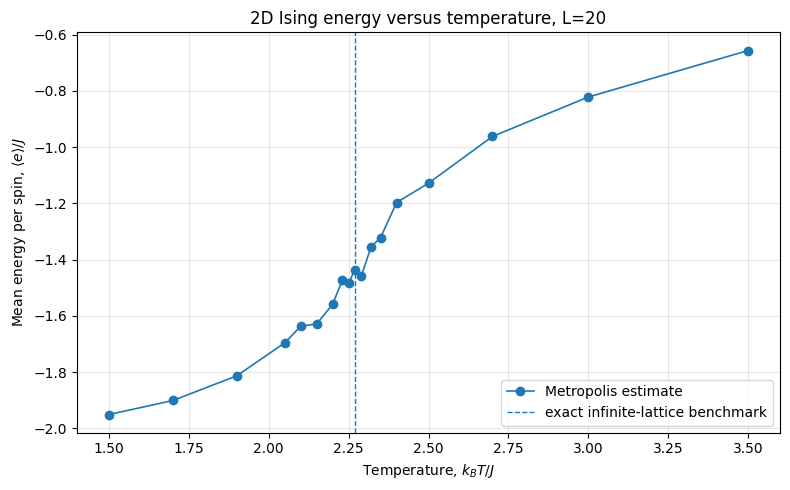

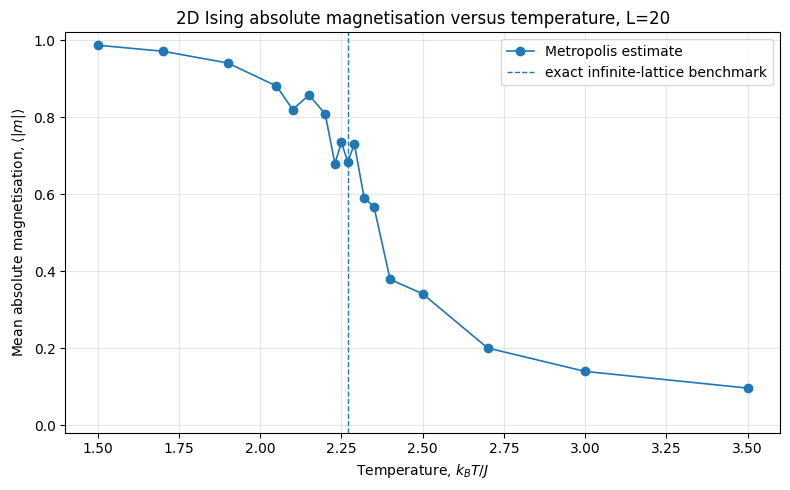

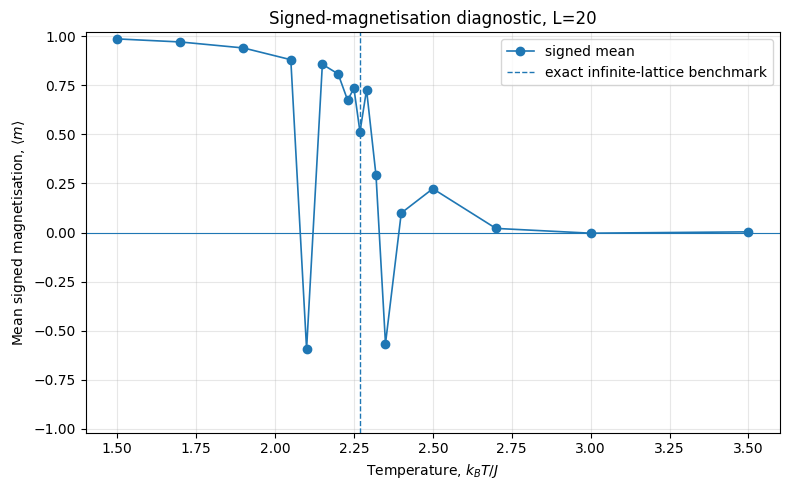

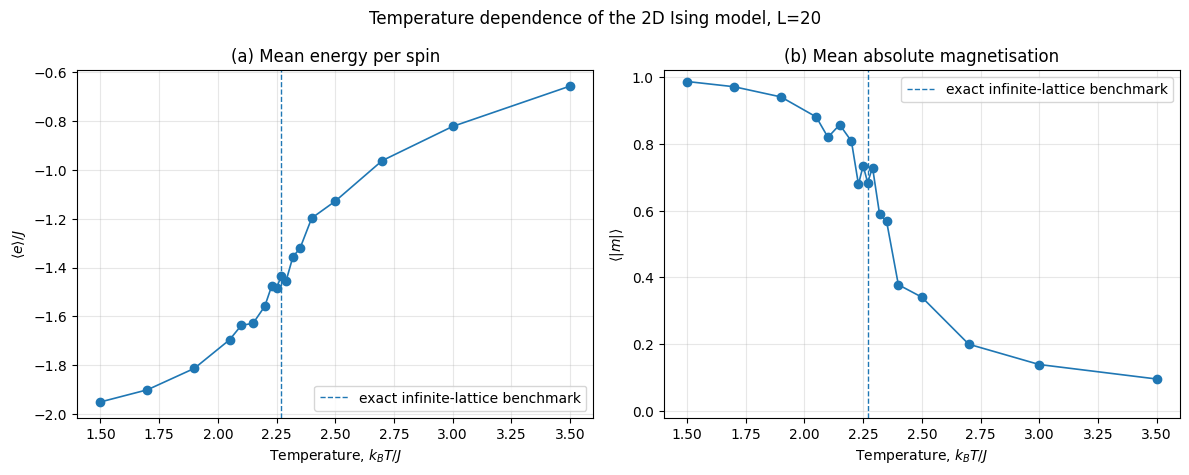

/mnt/data/ising-phase-transitions/figures/exploratory/classical/day22/energy_and_absolute_magnetisation_vs_temperature_L20.png


In [3]:

L = int(sweep["lattice_size"])

energy_path = FIGURE_DIR / f"energy_per_spin_vs_temperature_L{L}.png"
absolute_path = FIGURE_DIR / f"absolute_magnetisation_vs_temperature_L{L}.png"
signed_path = FIGURE_DIR / f"signed_magnetisation_vs_temperature_L{L}_diagnostic.png"
combined_path = FIGURE_DIR / f"energy_and_absolute_magnetisation_vs_temperature_L{L}.png"

plt.figure(figsize=(8, 5))
plt.plot(temperatures, mean_e, marker="o", linewidth=1.2, label="Metropolis estimate")
plt.axvline(TC_EXACT, linestyle="--", linewidth=1.0, label="exact infinite-lattice benchmark")
plt.xlabel(r"Temperature, $k_B T/J$")
plt.ylabel(r"Mean energy per spin, $\langle e\rangle/J$")
plt.title(f"2D Ising energy versus temperature, L={L}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(energy_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
plt.plot(temperatures, mean_abs_m, marker="o", linewidth=1.2, label="Metropolis estimate")
plt.axvline(TC_EXACT, linestyle="--", linewidth=1.0, label="exact infinite-lattice benchmark")
plt.xlabel(r"Temperature, $k_B T/J$")
plt.ylabel(r"Mean absolute magnetisation, $\langle |m|\rangle$")
plt.title(f"2D Ising absolute magnetisation versus temperature, L={L}")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(absolute_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
plt.plot(temperatures, mean_m, marker="o", linewidth=1.2, label="signed mean")
plt.axvline(TC_EXACT, linestyle="--", linewidth=1.0, label="exact infinite-lattice benchmark")
plt.axhline(0.0, linewidth=0.8)
plt.xlabel(r"Temperature, $k_B T/J$")
plt.ylabel(r"Mean signed magnetisation, $\langle m\rangle$")
plt.title(f"Signed-magnetisation diagnostic, L={L}")
plt.ylim(-1.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(signed_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

figure, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)
axes[0].plot(temperatures, mean_e, marker="o", linewidth=1.2)
axes[0].axvline(TC_EXACT, linestyle="--", linewidth=1.0, label="exact infinite-lattice benchmark")
axes[0].set_xlabel(r"Temperature, $k_B T/J$")
axes[0].set_ylabel(r"$\langle e\rangle/J$")
axes[0].set_title("(a) Mean energy per spin")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(temperatures, mean_abs_m, marker="o", linewidth=1.2)
axes[1].axvline(TC_EXACT, linestyle="--", linewidth=1.0, label="exact infinite-lattice benchmark")
axes[1].set_xlabel(r"Temperature, $k_B T/J$")
axes[1].set_ylabel(r"$\langle |m|\rangle$")
axes[1].set_title("(b) Mean absolute magnetisation")
axes[1].set_ylim(-0.02, 1.02)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

figure.suptitle(f"Temperature dependence of the 2D Ising model, L={L}")
figure.tight_layout()
figure.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)

print(combined_path)


## 3. Numerical extraction for the results narrative

The unequal temperature spacing means that the steepest interval is identified using adjacent finite-difference slopes, not only raw changes.

In [4]:

low_index = int(np.argmin(np.abs(temperatures - 1.5)))
high_index = int(np.argmin(np.abs(temperatures - 3.5)))

energy_slopes = np.diff(mean_e) / np.diff(temperatures)
magnetisation_slopes = np.diff(mean_abs_m) / np.diff(temperatures)
combined_score = np.abs(energy_slopes) + np.abs(magnetisation_slopes)
steep_index = int(np.argmax(combined_score))

print("Low-temperature comparison")
print(f"  T=1.5: <e> = {mean_e[low_index]:.5f}; distance from -2 = {mean_e[low_index] + 2.0:.5f}")
print(f"  T=1.5: <|m|> = {mean_abs_m[low_index]:.5f}; distance from 1 = {1.0 - mean_abs_m[low_index]:.5f}")

print("\nHigh-temperature movement")
print(f"  T=3.5: <e> = {mean_e[high_index]:.5f}; remaining distance from 0 = {abs(mean_e[high_index]):.5f}")
print(f"  T=3.5: <|m|> = {mean_abs_m[high_index]:.5f}; remaining distance from 0 = {mean_abs_m[high_index]:.5f}")

print("\nLargest joint adjacent finite-difference change")
print(f"  interval: {temperatures[steep_index]:.5f} to {temperatures[steep_index + 1]:.5f}")
print(f"  Δ<e>/ΔT = {energy_slopes[steep_index]:.5f}")
print(f"  Δ<|m|>/ΔT = {magnetisation_slopes[steep_index]:.5f}")


Low-temperature comparison
  T=1.5: <e> = -1.95107; distance from -2 = 0.04893
  T=1.5: <|m|> = 0.98655; distance from 1 = 0.01345

High-temperature movement
  T=3.5: <e> = -0.65621; remaining distance from 0 = 0.65621
  T=3.5: <|m|> = 0.09595; remaining distance from 0 = 0.09595

Largest joint adjacent finite-difference change
  interval: 2.29000 to 2.32000
  Δ<e>/ΔT = 3.38817
  Δ<|m|>/ΔT = -4.64900


## 4. First-half stability and initial-condition checks

The primary all-up chain is compared with an independently seeded random-start chain at $T=1.5$, $T_c$ and $T=3.5$. Energy and $|m|$ should be compared across starts. The signed $m$ may differ when the two chains occupy opposite symmetry sectors.

In [5]:

def sector_switches(values: np.ndarray) -> int:
    signs = np.sign(np.asarray(values, dtype=float))
    signs = signs[signs != 0.0]
    return int(np.sum(signs[1:] != signs[:-1])) if signs.size > 1 else 0


selected_temperatures = np.array([1.5, TC_EXACT, 3.5])
print(
    f"{'T':>10} {'e first':>12} {'e second':>12} "
    f"{'|m| first':>12} {'|m| second':>12} {'switches':>10}"
)
print("-" * 76)

for temperature in selected_temperatures:
    index = int(np.argmin(np.abs(temperatures - temperature)))
    e_trace = sweep["production_energy"][0, index] / int(sweep["n_spins"])
    abs_trace = sweep["production_absolute_magnetisation"][0, index]
    signed_trace = sweep["production_magnetisation"][0, index]
    e_first, e_second = split_half_means(e_trace)
    m_first, m_second = split_half_means(abs_trace)
    print(
        f"{temperatures[index]:>10.6f} {e_first:>12.5f} {e_second:>12.5f} "
        f"{m_first:>12.5f} {m_second:>12.5f} {sector_switches(signed_trace):>10d}"
    )

if DIAGNOSTIC_PATH.exists():
    diagnostic = load_npz(DIAGNOSTIC_PATH)
    print("\nAll-up primary versus random-start diagnostics")
    print(f"{'T':>10} {'start':>9} {'mean e':>12} {'mean m':>12} {'mean |m|':>12}")
    print("-" * 61)
    for diagnostic_index, temperature in enumerate(diagnostic["temperatures"]):
        primary_index = int(np.argmin(np.abs(temperatures - temperature)))
        print(
            f"{temperature:>10.6f} {'up':>9} "
            f"{mean_e[primary_index]:>12.5f} "
            f"{mean_m[primary_index]:>12.5f} "
            f"{mean_abs_m[primary_index]:>12.5f}"
        )
        random_m = diagnostic["production_magnetisation"][diagnostic_index]
        random_e = diagnostic["production_energy"][diagnostic_index] / int(sweep["n_spins"])
        print(
            f"{temperature:>10.6f} {'random':>9} "
            f"{np.mean(random_e):>12.5f} "
            f"{np.mean(random_m):>12.5f} "
            f"{np.mean(np.abs(random_m)):>12.5f}"
        )
else:
    print(f"Diagnostic file not present: {DIAGNOSTIC_PATH}")


         T      e first     e second    |m| first   |m| second   switches
----------------------------------------------------------------------------
  1.500000     -1.94972     -1.95243      0.98613      0.98696          0
  2.269185     -1.47378     -1.39960      0.74460      0.62335          9
  3.500000     -0.66019     -0.65224      0.09388      0.09802        366

All-up primary versus random-start diagnostics
         T     start       mean e       mean m     mean |m|
-------------------------------------------------------------
  1.500000        up     -1.95107      0.98655      0.98655
  1.500000    random     -1.95179      0.98683      0.98683
  2.269185        up     -1.43669      0.51259      0.68397
  2.269185    random     -1.43779     -0.64160      0.66869
  3.500000        up     -0.65621      0.00345      0.09595
  3.500000    random     -0.65839     -0.00091      0.09560


## Interpretation and limitations

At low temperature, the energy and absolute magnetisation should lie close to their ordered limits $-2$ and $1$. At high temperature they move towards zero, although finite temperature and finite lattice size leave residual correlations and a non-zero mean absolute magnetisation. The transition region is rounded because a finite partition function is analytic. The exact line at $T_c$ is a thermodynamic-limit benchmark.

The primary day-22 curve uses one seed per temperature and successive production samples are autocorrelated. It is therefore not a final phase-boundary estimate and no independent-sample error bars are assigned. The next extension is to increase the replicate dimension through the YAML configuration and then compute susceptibility, specific heat and defensible uncertainty estimates from the same saved $E$, $E^2$, $m$, $m^2$ and $|m|$ arrays.

## Figure caption

**Temperature dependence of energy and magnetic order in the finite two-dimensional Ising model.** Panel (a) shows the mean energy per spin and panel (b) the mean absolute magnetisation per spin for an $L=20$ periodic square lattice. Each temperature uses one independently seeded Metropolis chain with 1,000 burn-in and 2,000 production sweeps. The dashed line marks the exact infinite-lattice critical-temperature benchmark and is not a fitted finite-size transition. Connecting segments are guides to the eye. The final uncertainty intervals are deferred to the multiple-seed analysis.

## References

- Tong, D., *Statistical Physics*, Section 5.2, Section 5.2.3 and Section 5.3.4.
- Metropolis, N. et al. (1953), “Equation of State Calculations by Fast Computing Machines”.
- Onsager, L. (1944), “Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition”.
